# **Notebook 2: Text Encoder Selection for Dual-View X-ray Fusion**

**Description:** This notebook compares candidate clinical text encoders for the multimodal chest X-ray classifier while keeping the image branch, saved splits, label space, and training protocol aligned with Notebook 01. It evaluates CheXbert, Bio_ClinicalBERT, and RadBERT in both text-only and image/text fusion settings.

**Main Questions This Notebook Should Answer:**
- Does a domain-specific text encoder improve classification beyond the dual-view image baseline?
- Does the improvement show up in accuracy, macro F1, or both?
- Which text encoder should be carried forward into the residual gated fusion experiment?

---

# **Part 1: Configuration**
### **Imports**


In [1]:
from pathlib import Path
import sys
import gc
import json
import math
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TRANSFORMERS_NO_FLAX", "1")

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from transformers import AutoModel, AutoTokenizer, BertConfig, BertModel
from transformers.utils.hub import cached_file

# Ensure Python can find the local xray_fusion package.
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "src" / "xray_fusion").exists()),
    Path.cwd(),
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from xray_fusion.config import DEFAULT_IMAGE_SIZE, DEFAULT_MAX_LEN, find_project_root
from xray_fusion import data as xray_data
from xray_fusion import models as xray_models
from xray_fusion import training as xray_training
from xray_fusion import evaluation as xray_eval
from xray_fusion import segmentation as xray_segmentation
from xray_fusion import gradcam as xray_gradcam

BASE_SEED = 42
EXPERIMENT_SEEDS = [42]

seed_everything = xray_training.seed_everything
seed_everything(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


### **Paths**


In [2]:
project_root = Path.cwd().resolve()
if not (project_root / "splits").exists():
    project_root = project_root.parent

base_dir = project_root
split_dir = base_dir / "splits"

train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"

### **Configurations**


In [3]:
HF_CACHE_DIR = base_dir / "hf_cache"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 10

LR_TEXT = 2e-5
LR_IMAGE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_LEN = 64
FREEZE_BERT = True
FREEZE_IMAGE_BACKBONE = False

LR_SCHEDULE_NAME = "constant"
EXPERIMENT_NAME = "experiment_02_text_encoder_benchmark"


### **Benchmark Setup**


In [4]:
OUTPUT_DIR = base_dir / "Experiments" / "outputs" / EXPERIMENT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESOLVED_MODEL_CACHE_DIR = OUTPUT_DIR / "resolved_hf_models"
RESOLVED_MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("Saving artifacts to:", OUTPUT_DIR)

TEXT_ENCODER_SPECS = [
    {
        "name": "Bio_ClinicalBERT",
        "slug": "bio_clinicalbert",
        "loader": "auto",
        "model_name": "emilyalsentzer/Bio_ClinicalBERT",
        "tokenizer_name": "emilyalsentzer/Bio_ClinicalBERT",
    },
    {
        "name": "CheXbert",
        "slug": "chexbert",
        "loader": "chexbert",
        "repo_id": "StanfordAIMI/RRG_scorers",
        "filename": "chexbert.pth",
        "tokenizer_name": "bert-base-uncased",
    },
    {
        "name": "RadBERT",
        "slug": "radbert",
        "loader": "auto",
        "model_name": "StanfordAIMI/RadBERT",
        "tokenizer_name": "StanfordAIMI/RadBERT",
    },
]

print("Experiment seeds:", EXPERIMENT_SEEDS)
print("Text encoders configured:")
for spec in TEXT_ENCODER_SPECS:
    print(f" - {spec['name']} | tokenizer: {spec['tokenizer_name']}")


Saving artifacts to: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark
Experiment seeds: [42]
Text encoders configured:
 - Bio_ClinicalBERT | tokenizer: emilyalsentzer/Bio_ClinicalBERT
 - CheXbert | tokenizer: bert-base-uncased
 - RadBERT | tokenizer: StanfordAIMI/RadBERT


### **Load precomputed train, validation, and test splits**


In [5]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())


Train shape: (2200, 15)
Val shape: (472, 15)
Test shape: (472, 15)


,uid,frontal_filename,lateral_filename,MeSH,Problems,image,indication,comparison,findings,impression,frontal_path,lateral_path,frontal_exists,lateral_exists,clean_label
0,149,149_IM-0315-1001.dcm.png,149_IM-0315-1002.dcm.png,normal,normal,pa and lateral chest.,xxxx dyspnea,none.,NaN,heart size normal. lungs clear. no edema or ef...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal
1,1892,1892_IM-0580-1001.dcm.png,1892_IM-0580-2001.dcm.png,calcified granuloma/lung/lower lobe/right;oste...,calcified granuloma;osteophyte,pa and lateral views.,xxxx-year-old female. chest pain.,"xxxx, xxxx.",the cardiomediastinal silhouette is normal in ...,negative for acute abnormality.,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal
2,3880,3880_IM-1968-1001.dcm.png,3880_IM-1968-2001.dcm.png,cardiomegaly;opacity/lung/interstitial/promine...,cardiomegaly;opacity;pulmonary edema,"chest x-xxxx xxxx and lateral, xxxx .","xxxx-year-old female, dyspnea.","chest x-xxxx, xxxx",unchanged cardiomegaly. negative for pneumotho...,stable cardiomegaly with mild pulmonary inters...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,cardiomegaly
3,3334,3334_IM-1598-1001.dcm.png,3334_IM-1598-2001.dcm.png,infiltrate/lung/base/bilateral;pulmonary atele...,"infiltrate;pulmonary atelectasis;catheters, in...",portable chest xxxx xxxx at time xxxx,hypoxia. history: xxxx portable xxxx tubes and...,one xxxx xxxx,NaN,persistent but decreasing basilar infiltrates ...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,pneumonia_or_opacity
4,1994,1994_IM-0651-1001.dcm.png,1994_IM-0651-2001.dcm.png,normal,normal,"two-view chest xxxx, xxxx.",xxxx and nonproductive xxxx x1 xxxx.,none.,lungs are clear. no pneumothorax or pleural ef...,no acute cardiopulmonary abnormality.,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal


---

# **Part 2: Dataset Preparation**

The text-only, image-only, and fusion experiments all reuse the same labels, image transforms, split files, and class weighting so the encoder comparison stays controlled.
### **Encode Labels**


In [6]:
label_encoder = LabelEncoder()
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_enc"] = label_encoder.fit_transform(train_df["clean_label"])
val_df["label_enc"] = label_encoder.transform(val_df["clean_label"])
test_df["label_enc"] = label_encoder.transform(test_df["clean_label"])

label_names = list(label_encoder.classes_)
num_classes = len(label_names)

print("Classes:", label_names)

Classes: ['cardiomegaly', 'chronic_lung_disease', 'normal', 'pleural_effusion', 'pneumonia_or_opacity']


### **Image Transforms**


In [7]:
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


### **Dataset Classes**


In [8]:
class ClinicalTextDataset(xray_data.XRayTextDataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        super().__init__(df, tokenizer, max_len=max_len, label_key="labels")

class XRayMultimodalDataset(xray_data.XRayMultimodalDataset):
    def __init__(self, df, tokenizer, image_transform=None, max_len=MAX_LEN):
        super().__init__(df, tokenizer=tokenizer, image_transform=image_transform, max_len=max_len, label_key="labels")

class XRayDualImageDataset(xray_data.XRayDualImageDictDataset):
    def __init__(self, df, image_transform=None):
        super().__init__(df, image_transform=image_transform, label_key="labels")


### **Build dataloader helpers**


In [9]:
def make_torch_generator(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def make_loader(dataset, seed, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=make_torch_generator(seed) if shuffle else None,
    )


def load_tokenizer_for_encoder(encoder_spec):
    tokenizer_name = encoder_spec["tokenizer_name"]
    local_source = resolve_tokenizer_source(tokenizer_name)
    tokenizer_source = local_source if local_source is not None else tokenizer_name
    local_only = local_source is not None
    print(f"Loading tokenizer for {encoder_spec['name']}: {tokenizer_source}")
    return AutoTokenizer.from_pretrained(
        tokenizer_source,
        cache_dir=HF_CACHE_DIR,
        local_files_only=local_only,
    )


def build_text_loaders(tokenizer, seed):
    train_ds = ClinicalTextDataset(train_df, tokenizer)
    val_ds = ClinicalTextDataset(val_df, tokenizer)
    test_ds = ClinicalTextDataset(test_df, tokenizer)
    return (
        make_loader(train_ds, seed=seed, shuffle=True),
        make_loader(val_ds, seed=seed, shuffle=False),
        make_loader(test_ds, seed=seed, shuffle=False),
    )


def build_multimodal_loaders(tokenizer, seed):
    train_ds = XRayMultimodalDataset(train_df, tokenizer, image_transform=image_transform)
    val_ds = XRayMultimodalDataset(val_df, tokenizer, image_transform=image_transform)
    test_ds = XRayMultimodalDataset(test_df, tokenizer, image_transform=image_transform)
    return (
        make_loader(train_ds, seed=seed, shuffle=True),
        make_loader(val_ds, seed=seed, shuffle=False),
        make_loader(test_ds, seed=seed, shuffle=False),
    )


def build_image_loaders(seed):
    train_ds = XRayDualImageDataset(train_df, image_transform=image_transform)
    val_ds = XRayDualImageDataset(val_df, image_transform=image_transform)
    test_ds = XRayDualImageDataset(test_df, image_transform=image_transform)
    return (
        make_loader(train_ds, seed=seed, shuffle=True),
        make_loader(val_ds, seed=seed, shuffle=False),
        make_loader(test_ds, seed=seed, shuffle=False),
    )

sample_img_loader, _, _ = build_image_loaders(BASE_SEED)
sample_batch = next(iter(sample_img_loader))
for key, value in sample_batch.items():
    print(key, tuple(value.shape))


frontal (32, 3, 224, 224)
lateral (32, 3, 224, 224)
labels (32,)


### **Class Weights**


In [10]:
class_counts = train_df["clean_label"].value_counts()
class_weights = torch.tensor(
    [len(train_df) / class_counts[label] for label in label_names],
    dtype=torch.float32,
    device=device,
)


---

# **Part 3: Model and Training Utilities**

### **Model Classes**


In [11]:
get_cls_embedding = xray_models.get_cls_embedding
hf_repo_cache_dir = lambda repo_id, cache_dir=HF_CACHE_DIR: xray_models.hf_repo_cache_dir(repo_id, cache_dir)
iter_hf_snapshots = lambda repo_id, cache_dir=HF_CACHE_DIR: xray_models.iter_hf_snapshots(repo_id, cache_dir)
first_cached_file = lambda repo_id, filenames, cache_dir=HF_CACHE_DIR: xray_models.first_cached_file(repo_id, filenames, cache_dir)
copy_if_needed = xray_models.copy_if_needed
materialize_cached_repo = lambda repo_id, required_files, optional_files=None, cache_dir=HF_CACHE_DIR: xray_models.materialize_cached_repo(
    repo_id, required_files, optional_files=optional_files, cache_dir=cache_dir, resolved_dir=RESOLVED_MODEL_CACHE_DIR
)
resolve_model_source = lambda model_name: xray_models.resolve_model_source(model_name, HF_CACHE_DIR, RESOLVED_MODEL_CACHE_DIR)
resolve_tokenizer_source = lambda tokenizer_name: xray_models.resolve_tokenizer_source(tokenizer_name, HF_CACHE_DIR, RESOLVED_MODEL_CACHE_DIR)
load_auto_backbone = lambda model_name, cache_dir=None: xray_models.load_auto_backbone(
    model_name, cache_dir=cache_dir or HF_CACHE_DIR, resolved_dir=RESOLVED_MODEL_CACHE_DIR
)
load_chexbert_backbone = xray_models.load_chexbert_backbone

def load_text_backbone(spec, cache_dir=None):
    if spec["loader"] == "auto":
        backbone = load_auto_backbone(spec["model_name"], cache_dir=cache_dir)
    else:
        backbone = load_chexbert_backbone(
            spec["repo_id"],
            spec["filename"],
            cache_dir=cache_dir
        )

    return backbone, backbone.config.hidden_size

class TextOnlyClassifier(xray_models.TextOnlyClassifier):
    def __init__(self, encoder_spec, num_classes, freeze_bert=False, cache_dir=None):
        super().__init__(
            encoder_spec,
            num_classes,
            freeze_bert=freeze_bert,
            cache_dir=cache_dir,
            resolved_dir=RESOLVED_MODEL_CACHE_DIR
        )

DualImageEncoder = xray_models.DualImageEncoder
DualImageClassifier = xray_models.DualImageClassifier

class FusionClassifier(xray_models.FusionClassifier):
    def __init__(
        self,
        encoder_spec,
        num_classes,
        freeze_bert=False,
        freeze_image_backbone=False,
        cache_dir=None
    ):
        super().__init__(
            encoder_spec,
            num_classes,
            freeze_bert=freeze_bert,
            freeze_image_backbone=freeze_image_backbone,
            cache_dir=cache_dir,
            resolved_dir=RESOLVED_MODEL_CACHE_DIR,
        )

### **Training Functions**


In [12]:
configure_optimizer = lambda model, lr_text=LR_TEXT, lr_image=LR_IMAGE, weight_decay=WEIGHT_DECAY: xray_training.configure_optimizer(
    model, lr_text=lr_text, lr_image=lr_image, weight_decay=weight_decay
)
build_scheduler = xray_training.build_scheduler
move_batch_to_device = xray_training.move_task_batch_to_device
forward_task = xray_training.forward_task
train_one_epoch = xray_training.train_one_epoch
evaluate_model = xray_training.evaluate_model


### **Metric and Artifact Helpers**


In [13]:
safe_metric = xray_eval.safe_metric
compute_probability_metrics = xray_eval.compute_probability_metrics
compute_metrics = xray_eval.compute_metrics
save_json = xray_eval.save_json
plot_history = xray_eval.plot_history
classification_report_dict = xray_eval.classification_report_dict

def save_confusion_matrix_figure(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def checkpoint_payload(model, optimizer, scheduler, encoder_spec, task_type, seed, best_epoch, best_val_acc, config_extra=None):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "encoder_spec": encoder_spec,
        "task_type": task_type,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "config": config_extra or {},
    }

def save_split_artifacts(split_name, metrics, report, cm, run_dir, title_prefix):
    save_json(metrics, run_dir / f"{split_name}_metrics.json")
    save_json(report, run_dir / f"{split_name}_classification_report.json")
    pd.DataFrame(cm, index=label_names, columns=label_names).to_csv(run_dir / f"{split_name}_confusion_matrix.csv")
    save_confusion_matrix_figure(cm, f"{title_prefix} {split_name.title()} Confusion Matrix", run_dir / f"{split_name}_confusion_matrix.png")

def extract_per_class_rows(report, encoder_name, encoder_slug, task_type, seed, split_name):
    rows = []
    for class_name in label_names:
        class_metrics = report.get(class_name, {})
        rows.append({
            "encoder_name": encoder_name,
            "encoder_slug": encoder_slug,
            "task_type": task_type,
            "seed": seed,
            "split": split_name,
            "class_name": class_name,
            "precision": class_metrics.get("precision", np.nan),
            "recall": class_metrics.get("recall", np.nan),
            "f1_score": class_metrics.get("f1-score", np.nan),
            "support": class_metrics.get("support", np.nan),
        })
    return pd.DataFrame(rows)


### **Run Helper**


In [14]:
def train_and_evaluate_run(encoder_spec, task_type, seed):
    seed_everything(seed)

    if task_type == "image_only":
        encoder_name = "DualImageResNet18"
        encoder_slug = "dual_image_resnet18"
        run_slug = "dual_image_baseline"
        tokenizer_name = None
    else:
        encoder_name = encoder_spec["name"]
        encoder_slug = encoder_spec["slug"]
        run_slug = f"{encoder_slug}_{task_type}"
        tokenizer_name = encoder_spec["tokenizer_name"]

    run_dir = OUTPUT_DIR / run_slug / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = run_dir / "best_checkpoint.pt"

    if task_type == "image_only":
        model = DualImageClassifier(
            num_classes=num_classes,
            freeze_image_backbone=FREEZE_IMAGE_BACKBONE,
        ).to(device)
        train_loader, val_loader, test_loader = build_image_loaders(seed)
        run_title = "Dual-Image ResNet18 Baseline"
    elif task_type == "text_only":
        tokenizer = load_tokenizer_for_encoder(encoder_spec)
        model = TextOnlyClassifier(
            encoder_spec=encoder_spec,
            num_classes=num_classes,
            freeze_bert=FREEZE_BERT,
            cache_dir=HF_CACHE_DIR,
        ).to(device)
        train_loader, val_loader, test_loader = build_text_loaders(tokenizer, seed)
        run_title = f"{encoder_name} Text-Only"
    elif task_type == "fusion":
        tokenizer = load_tokenizer_for_encoder(encoder_spec)
        model = FusionClassifier(
            encoder_spec=encoder_spec,
            num_classes=num_classes,
            freeze_bert=FREEZE_BERT,
            freeze_image_backbone=FREEZE_IMAGE_BACKBONE,
            cache_dir=HF_CACHE_DIR,
        ).to(device)
        train_loader, val_loader, test_loader = build_multimodal_loaders(tokenizer, seed)
        run_title = f"{encoder_name} Fusion"
    else:
        raise ValueError(f"Unsupported task_type: {task_type}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = configure_optimizer(model)
    scheduler = build_scheduler(optimizer)

    history = []
    best_val_acc = -math.inf
    best_epoch = -1

    for epoch in range(1, EPOCHS + 1):
        print(f"{run_title} - Epoch {epoch}/{EPOCHS}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            task_type=task_type,
            desc=f"Train {run_slug}",
        )

        val_loss, val_acc, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            task_type=task_type,
            desc=f"Val {run_slug}",
        )

        scheduler.step()

        lr_values = [group["lr"] for group in optimizer.param_groups]
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr_min": min(lr_values),
                "lr_max": max(lr_values),
            }
        )

        print(
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )
        print()

        if val_acc >= best_val_acc:
            best_val_acc = float(val_acc)
            best_epoch = epoch
            torch.save(
                checkpoint_payload(
                    model,
                    optimizer,
                    scheduler,
                    encoder_spec,
                    task_type,
                    seed,
                    epoch,
                    best_val_acc,
                ),
                checkpoint_path,
            )

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "training_history.csv", index=False)
    plot_history(history_df, run_title, run_dir / "training_curves.png")

    best_checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])

    val_loss, val_acc, val_y_true, val_y_pred, val_y_prob = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
        task_type=task_type,
        desc=f"Best Val {run_slug}",
    )
    test_loss, test_acc, test_y_true, test_y_pred, test_y_prob = evaluate_model(
        model,
        test_loader,
        criterion,
        device,
        task_type=task_type,
        desc=f"Test {run_slug}",
    )

    val_metrics = compute_metrics(val_y_true, val_y_pred, val_y_prob, label_names)
    test_metrics = compute_metrics(test_y_true, test_y_pred, test_y_prob, label_names)
    val_report = classification_report_dict(val_y_true, val_y_pred, label_names)
    test_report = classification_report_dict(test_y_true, test_y_pred, label_names)
    val_cm = confusion_matrix(val_y_true, val_y_pred, labels=np.arange(len(label_names)))
    test_cm = confusion_matrix(test_y_true, test_y_pred, labels=np.arange(len(label_names)))

    save_split_artifacts("validation", val_metrics, val_report, val_cm, run_dir, run_title)
    save_split_artifacts("test", test_metrics, test_report, test_cm, run_dir, run_title)

    run_summary = {
        "encoder_name": encoder_name,
        "encoder_slug": encoder_slug,
        "task_type": task_type,
        "seed": seed,
        "tokenizer_name": tokenizer_name,
        "best_epoch": best_epoch,
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_macro_auroc": float(val_metrics["macro_auroc"]),
        "val_macro_auprc": float(val_metrics["macro_auprc"]),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "test_macro_auroc": float(test_metrics["macro_auroc"]),
        "test_macro_auprc": float(test_metrics["macro_auprc"]),
        "checkpoint_path": str(checkpoint_path),
        "run_dir": str(run_dir),
    }
    save_json(run_summary, run_dir / "run_summary.json")

    per_class_frames = [
        extract_per_class_rows(val_report, encoder_name, encoder_slug, task_type, seed, "validation"),
        extract_per_class_rows(test_report, encoder_name, encoder_slug, task_type, seed, "test"),
    ]
    run_per_class_df = pd.concat(per_class_frames, ignore_index=True)
    run_per_class_df.to_csv(run_dir / "per_class_metrics_all_splits.csv", index=False)

    display(history_df.tail(1))
    display(run_per_class_df)

    print(f"{run_title} validation accuracy:", round(run_summary["val_accuracy"], 4))
    print(f"{run_title} test accuracy:", round(run_summary["test_accuracy"], 4))
    print(f"{run_title} test macro F1:", round(run_summary["test_macro_f1"], 4))
    print(f"{run_title} test macro AUROC:", round(run_summary["test_macro_auroc"], 4))
    print(f"{run_title} test macro AUPRC:", round(run_summary["test_macro_auprc"], 4))
    print("Best checkpoint:", checkpoint_path)
    print()

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return run_summary, run_per_class_df


### **Benchmark Helpers**


In [15]:
def get_encoder_spec(name_or_slug):
    requested = str(name_or_slug).lower()
    for spec in TEXT_ENCODER_SPECS:
        candidates = {spec["name"].lower(), spec["slug"].lower()}
        if requested in candidates:
            return spec
    available = ", ".join(spec["name"] for spec in TEXT_ENCODER_SPECS)
    raise ValueError(f"Unknown encoder '{name_or_slug}'. Available encoders: {available}")


def clean_imported_summary(summary, source_label):
    summary = dict(summary)
    for metadata_key in ("tokenizer" + "_note", "description"):
        summary.pop(metadata_key, None)
    summary["tokenizer_name"] = summary.get("tokenizer_name") or "not_applicable"
    summary["source_notebook"] = source_label
    return summary


def load_saved_dual_image_baseline():
    baseline_dir = OUTPUT_DIR / "dual_image_baseline"
    rows = []
    per_class_tables = []

    for seed in EXPERIMENT_SEEDS:
        run_dir = baseline_dir / f"seed_{seed}"
        summary_path = run_dir / "run_summary.json"
        per_class_path = run_dir / "per_class_metrics_all_splits.csv"
        if not summary_path.exists() or not per_class_path.exists():
            return [], []

        with open(summary_path, "r", encoding="utf-8") as handle:
            rows.append(clean_imported_summary(json.load(handle), "02 saved dual-image baseline artifacts"))
        per_class_tables.append(pd.read_csv(per_class_path))

    return rows, per_class_tables


def import_saved_image_baseline(run_summaries, per_class_tables):
    baseline_rows, baseline_per_class_tables = load_saved_dual_image_baseline()
    if not baseline_rows:
        raise FileNotFoundError(
            "Saved dual-image baseline artifacts were not found. Run Notebook 01/previous baseline first, "
            "or restore Experiments/outputs/experiment_02_text_encoder_benchmark/dual_image_baseline/seed_* artifacts."
        )

    run_summaries.extend(baseline_rows)
    per_class_tables.extend(baseline_per_class_tables)

    baseline_df = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
    baseline_per_class_df = pd.concat(baseline_per_class_tables, ignore_index=True)

    display(baseline_df)
    display(baseline_per_class_df.head(10))
    print("Imported saved dual-image baseline artifact for seed 42.")
    print("Seed 42 test accuracy:", round(float(baseline_df["test_accuracy"].iloc[0]), 4))
    print("Seed 42 test macro F1:", round(float(baseline_df["test_macro_f1"].iloc[0]), 4))
    print()

    return baseline_df, baseline_per_class_df


def train_encoder_variation(encoder_spec, run_summaries, per_class_tables):
    print("=" * 80)
    print(f"Starting runs for {encoder_spec['name']}")
    print("=" * 80)

    for task_type in ["text_only", "fusion"]:
        for seed in EXPERIMENT_SEEDS:
            run_summary, run_per_class_df = train_and_evaluate_run(encoder_spec, task_type, seed)
            run_summaries.append(run_summary)
            per_class_tables.append(run_per_class_df)

def build_benchmark_summary_tables(run_summaries, per_class_tables):
    run_summary_df = pd.DataFrame(run_summaries)
    if not run_summary_df.empty:
        task_order = {"image_only": 0, "text_only": 1, "fusion": 2}
        run_summary_df["task_rank"] = run_summary_df["task_type"].map(task_order).fillna(99)
        run_summary_df = run_summary_df.sort_values(
            ["task_rank", "encoder_name", "seed"],
            ascending=[True, True, True],
        ).drop(columns=["task_rank"]).reset_index(drop=True)
        run_summary_df.to_csv(OUTPUT_DIR / "run_summary.csv", index=False)

        aggregate_rows = []
        group_cols = ["encoder_name", "encoder_slug", "task_type", "tokenizer_name"]
        metric_cols = ["test_accuracy", "test_macro_f1", "test_macro_auroc", "test_macro_auprc"]
        for group_key, group_df in run_summary_df.groupby(group_cols, dropna=False):
            row = dict(zip(group_cols, group_key))
            for metric_col in metric_cols:
                metric_values = group_df[metric_col].dropna().astype(float)
                row[f"{metric_col}_mean"] = float(metric_values.mean()) if not metric_values.empty else np.nan
            aggregate_rows.append(row)

        aggregate_summary_df = pd.DataFrame(aggregate_rows)
        aggregate_summary_df = aggregate_summary_df.sort_values(
            ["task_type", "test_accuracy_mean", "test_macro_f1_mean"],
            ascending=[True, False, False],
        ).reset_index(drop=True)
        aggregate_summary_df.to_csv(OUTPUT_DIR / "aggregate_summary.csv", index=False)
        save_json(aggregate_summary_df.to_dict(orient="records"), OUTPUT_DIR / "aggregate_summary.json")
    else:
        aggregate_summary_df = pd.DataFrame()

    if per_class_tables:
        per_class_summary_df = pd.concat(per_class_tables, ignore_index=True)
        per_class_summary_df.to_csv(OUTPUT_DIR / "per_class_summary.csv", index=False)
    else:
        per_class_summary_df = pd.DataFrame()

    print("Benchmark summaries refreshed.")
    if not run_summary_df.empty:
        print("Run summary CSV:", OUTPUT_DIR / "run_summary.csv")
    if not aggregate_summary_df.empty:
        print("Aggregate summary CSV:", OUTPUT_DIR / "aggregate_summary.csv")
    if not per_class_summary_df.empty:
        print("Per-class summary CSV:", OUTPUT_DIR / "per_class_summary.csv")
    return run_summary_df, aggregate_summary_df, per_class_summary_df


### **Initialize Benchmark Tracking**


In [16]:
run_summaries = []
per_class_tables = []


---

# **Part 4: Train Models**

### **Import Saved Dual-Image Baseline**


In [17]:
import_saved_image_baseline(run_summaries, per_class_tables)


,encoder_name,encoder_slug,task_type,seed,tokenizer_name,best_epoch,val_loss,val_accuracy,val_macro_f1,val_macro_auroc,val_macro_auprc,test_loss,test_accuracy,test_macro_f1,test_macro_auroc,test_macro_auprc,checkpoint_path,run_dir,source_notebook
0,DualImageResNet18,dual_image_resnet18,image_only,42,not_applicable,5,2.472141,0.766949,0.431304,0.819118,0.482566,2.886285,0.756356,0.359514,0.779358,0.449066,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,02 saved dual-image baseline artifacts


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1-score,support,auroc,auprc
0,DualImageResNet18,dual_image_resnet18,image_only,42,validation,cardiomegaly,0.916667,0.289474,0.440000,38.0,0.927844,0.613404
1,DualImageResNet18,dual_image_resnet18,image_only,42,validation,chronic_lung_disease,0.666667,0.250000,0.363636,16.0,0.903920,0.389814
2,DualImageResNet18,dual_image_resnet18,image_only,42,validation,normal,0.799043,0.965318,0.874346,346.0,0.791495,0.900891
3,DualImageResNet18,dual_image_resnet18,image_only,42,validation,pleural_effusion,0.444444,0.160000,0.235294,25.0,0.728054,0.239120
4,DualImageResNet18,dual_image_resnet18,image_only,42,validation,pneumonia_or_opacity,0.333333,0.191489,0.243243,47.0,0.744280,0.269600
5,DualImageResNet18,dual_image_resnet18,image_only,42,test,cardiomegaly,0.800000,0.105263,0.186047,38.0,0.884004,0.507307
6,DualImageResNet18,dual_image_resnet18,image_only,42,test,chronic_lung_disease,0.666667,0.117647,0.200000,17.0,0.830899,0.338992
7,DualImageResNet18,dual_image_resnet18,image_only,42,test,normal,0.790094,0.971014,0.871261,345.0,0.765286,0.887780
8,DualImageResNet18,dual_image_resnet18,image_only,42,test,pleural_effusion,0.444444,0.153846,0.228571,26.0,0.711970,0.216089
9,DualImageResNet18,dual_image_resnet18,image_only,42,test,pneumonia_or_opacity,0.387097,0.260870,0.311688,46.0,0.704634,0.295164


Imported saved dual-image baseline artifact for seed 42.
Seed 42 test accuracy: 0.7564
Seed 42 test macro F1: 0.3595



(        encoder_name         encoder_slug   task_type  seed  tokenizer_name  \
 0  DualImageResNet18  dual_image_resnet18  image_only    42  not_applicable   
 
    best_epoch  val_loss  val_accuracy  val_macro_f1  val_macro_auroc  \
 0           5  2.472141      0.766949      0.431304         0.819118   
 
    val_macro_auprc  test_loss  test_accuracy  test_macro_f1  test_macro_auroc  \
 0         0.482566   2.886285       0.756356       0.359514          0.779358   
 
    test_macro_auprc                                    checkpoint_path  \
 0          0.449066  PROJECT_ROOT\Exp...   
 
                                              run_dir  \
 0  PROJECT_ROOT\Exp...   
 
                           source_notebook  
 0  02 saved dual-image baseline artifacts  ,
         encoder_name         encoder_slug   task_type  seed       split  \
 0  DualImageResNet18  dual_image_resnet18  image_only    42  validation   
 1  DualImageResNet18  dual_image_resnet18  image_only    42  validation 

### **Train CheXbert Text Encoder Variation**


Starting runs for CheXbert
Loading tokenizer for CheXbert: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\bert-base-uncased
CheXbert Text-Only - Epoch 1/10


Train chexbert_text_only:   0%|                                                                 | 0/69 [00:00<…

Val chexbert_text_only:   0%|                                                                   | 0/15 [00:00<…

train_loss=1.6435 | train_acc=0.2641 | val_loss=1.6496 | val_acc=0.3644

CheXbert Text-Only - Epoch 2/10


Train chexbert_text_only:   0%|                                                                 | 0/69 [00:00<…

...

Train chexbert_text_only:   0%|                                                                 | 0/69 [00:00<…

Val chexbert_text_only:   0%|                                                                   | 0/15 [00:00<…

train_loss=1.5519 | train_acc=0.3795 | val_loss=1.5889 | val_acc=0.4343



Best Val chexbert_text_only:   0%|                                                              | 0/15 [00:00<…

Test chexbert_text_only:   0%|                                                                  | 0/15 [00:00<…

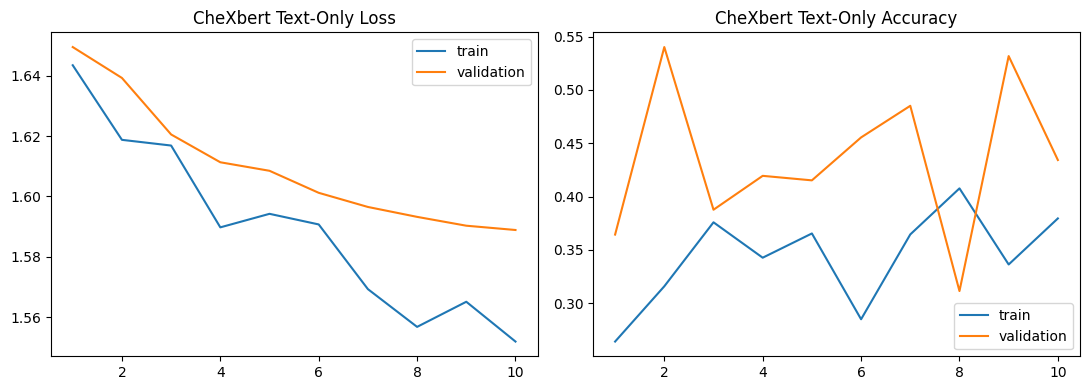

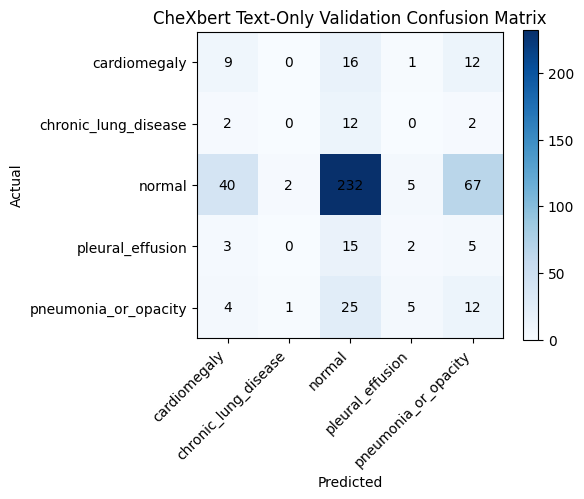

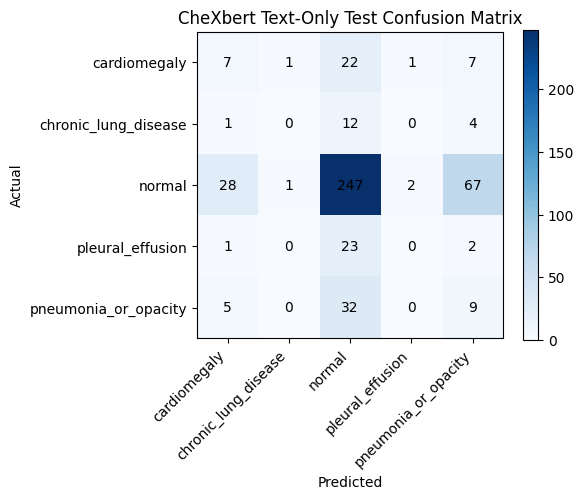

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,1.551877,0.379545,1.588878,0.434322,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,CheXbert,chexbert,text_only,42,validation,cardiomegaly,0.155172,0.236842,0.187500,38.0
1,CheXbert,chexbert,text_only,42,validation,chronic_lung_disease,0.000000,0.000000,0.000000,16.0
2,CheXbert,chexbert,text_only,42,validation,normal,0.773333,0.670520,0.718266,346.0
3,CheXbert,chexbert,text_only,42,validation,pleural_effusion,0.153846,0.080000,0.105263,25.0
4,CheXbert,chexbert,text_only,42,validation,pneumonia_or_opacity,0.122449,0.255319,0.165517,47.0
5,CheXbert,chexbert,text_only,42,test,cardiomegaly,0.166667,0.184211,0.175000,38.0
6,CheXbert,chexbert,text_only,42,test,chronic_lung_disease,0.000000,0.000000,0.000000,17.0
7,CheXbert,chexbert,text_only,42,test,normal,0.735119,0.715942,0.725404,345.0
8,CheXbert,chexbert,text_only,42,test,pleural_effusion,0.000000,0.000000,0.000000,26.0
9,CheXbert,chexbert,text_only,42,test,pneumonia_or_opacity,0.101124,0.195652,0.133333,46.0


CheXbert Text-Only validation accuracy: 0.5403
CheXbert Text-Only test accuracy: 0.5572
CheXbert Text-Only test macro F1: 0.2067
CheXbert Text-Only test macro AUROC: 0.597
CheXbert Text-Only test macro AUPRC: 0.2424
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\chexbert_text_only\seed_42\best_checkpoint.pt

Loading tokenizer for CheXbert: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\bert-base-uncased
CheXbert Fusion - Epoch 1/10


Train chexbert_fusion:   0%|                                                                    | 0/69 [00:00<…

Val chexbert_fusion:   0%|                                                                      | 0/15 [00:00<…

...

Train chexbert_fusion:   0%|                                                                    | 0/69 [00:00<…

Val chexbert_fusion:   0%|                                                                      | 0/15 [00:00<…

train_loss=0.0039 | train_acc=1.0000 | val_loss=3.4033 | val_acc=0.7712



Best Val chexbert_fusion:   0%|                                                                 | 0/15 [00:00<…

Test chexbert_fusion:   0%|                                                                     | 0/15 [00:00<…

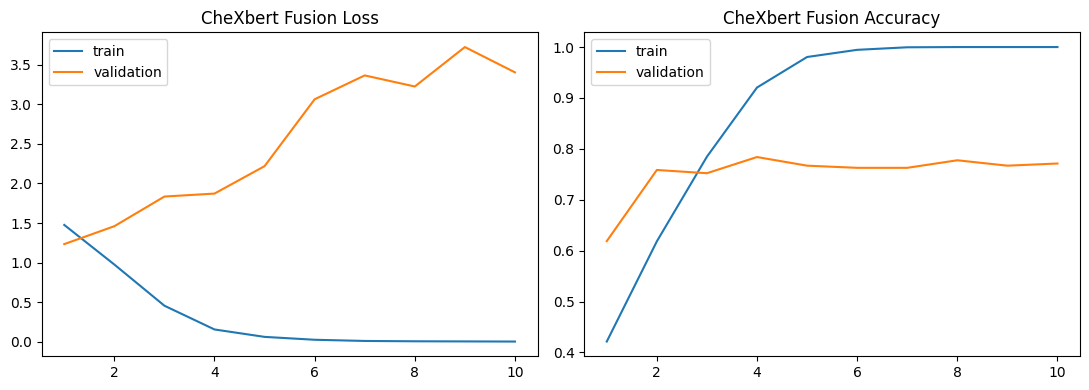

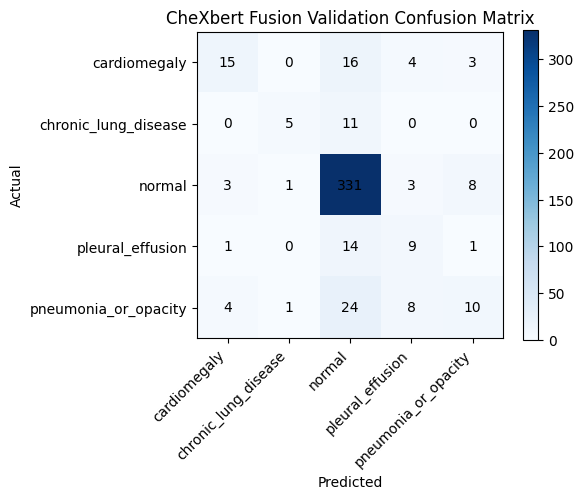

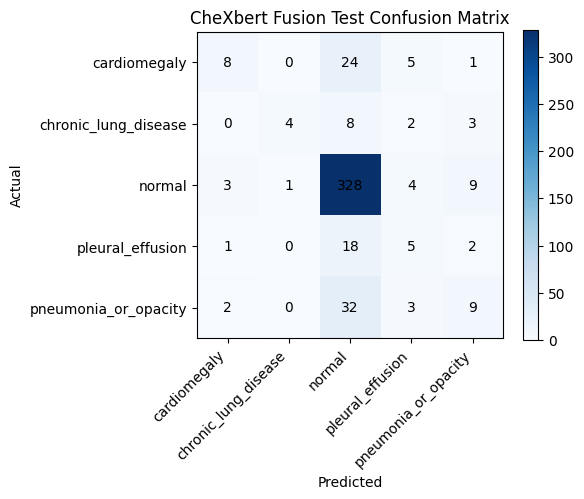

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,0.00389,1.0,3.40331,0.771186,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,CheXbert,chexbert,fusion,42,validation,cardiomegaly,0.652174,0.394737,0.491803,38.0
1,CheXbert,chexbert,fusion,42,validation,chronic_lung_disease,0.714286,0.312500,0.434783,16.0
2,CheXbert,chexbert,fusion,42,validation,normal,0.835859,0.956647,0.892183,346.0
3,CheXbert,chexbert,fusion,42,validation,pleural_effusion,0.375000,0.360000,0.367347,25.0
4,CheXbert,chexbert,fusion,42,validation,pneumonia_or_opacity,0.454545,0.212766,0.289855,47.0
5,CheXbert,chexbert,fusion,42,test,cardiomegaly,0.571429,0.210526,0.307692,38.0
6,CheXbert,chexbert,fusion,42,test,chronic_lung_disease,0.800000,0.235294,0.363636,17.0
7,CheXbert,chexbert,fusion,42,test,normal,0.800000,0.950725,0.868874,345.0
8,CheXbert,chexbert,fusion,42,test,pleural_effusion,0.263158,0.192308,0.222222,26.0
9,CheXbert,chexbert,fusion,42,test,pneumonia_or_opacity,0.375000,0.195652,0.257143,46.0


CheXbert Fusion validation accuracy: 0.7839
CheXbert Fusion test accuracy: 0.75
CheXbert Fusion test macro F1: 0.4039
CheXbert Fusion test macro AUROC: 0.7847
CheXbert Fusion test macro AUPRC: 0.4403
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\chexbert_fusion\seed_42\best_checkpoint.pt



In [19]:
chexbert_spec = get_encoder_spec("chexbert")
train_encoder_variation(chexbert_spec, run_summaries, per_class_tables)


### **Train Bio_ClinicalBERT Text Encoder Variation**


Starting runs for Bio_ClinicalBERT
Loading tokenizer for Bio_ClinicalBERT: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bio_ClinicalBERT Text-Only - Epoch 1/10


Train bio_clinicalbert_text_only:   0%|                                                         | 0/69 [00:00<…

...

Train bio_clinicalbert_text_only:   0%|                                                         | 0/69 [00:00<…

Val bio_clinicalbert_text_only:   0%|                                                           | 0/15 [00:00<…

train_loss=1.5524 | train_acc=0.3982 | val_loss=1.5599 | val_acc=0.4025



Best Val bio_clinicalbert_text_only:   0%|                                                      | 0/15 [00:00<…

Test bio_clinicalbert_text_only:   0%|                                                          | 0/15 [00:00<…

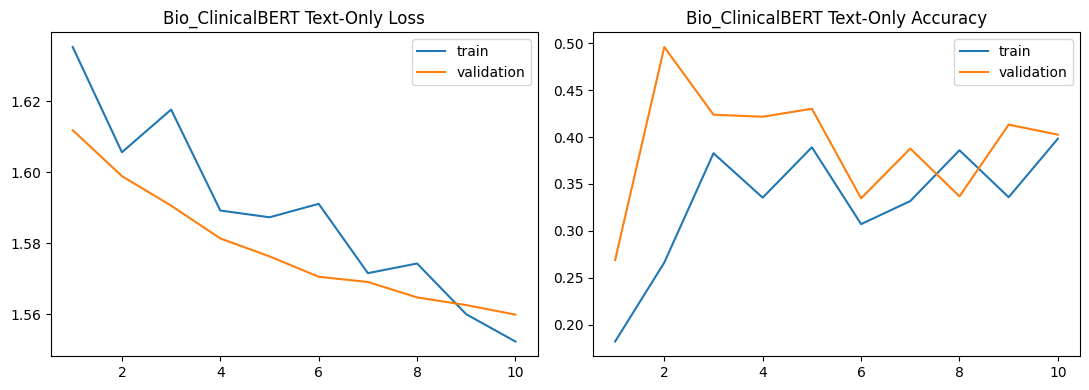

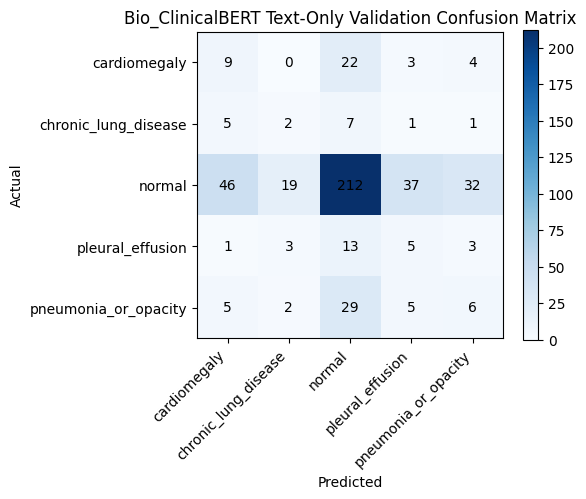

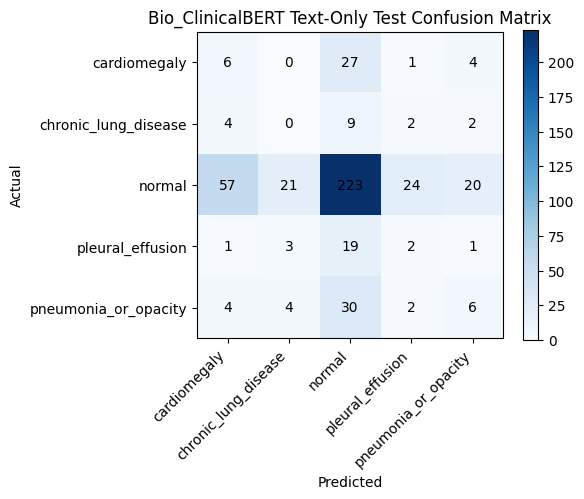

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,1.552374,0.398182,1.559943,0.402542,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,validation,cardiomegaly,0.136364,0.236842,0.173077,38.0
1,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,validation,chronic_lung_disease,0.076923,0.125000,0.095238,16.0
2,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,validation,normal,0.749117,0.612717,0.674086,346.0
3,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,validation,pleural_effusion,0.098039,0.200000,0.131579,25.0
4,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,validation,pneumonia_or_opacity,0.130435,0.127660,0.129032,47.0
5,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,test,cardiomegaly,0.083333,0.157895,0.109091,38.0
6,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,test,chronic_lung_disease,0.000000,0.000000,0.000000,17.0
7,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,test,normal,0.724026,0.646377,0.683002,345.0
8,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,test,pleural_effusion,0.064516,0.076923,0.070175,26.0
9,Bio_ClinicalBERT,bio_clinicalbert,text_only,42,test,pneumonia_or_opacity,0.181818,0.130435,0.151899,46.0


Bio_ClinicalBERT Text-Only validation accuracy: 0.4958
Bio_ClinicalBERT Text-Only test accuracy: 0.5021
Bio_ClinicalBERT Text-Only test macro F1: 0.2028
Bio_ClinicalBERT Text-Only test macro AUROC: 0.5617
Bio_ClinicalBERT Text-Only test macro AUPRC: 0.225
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\bio_clinicalbert_text_only\seed_42\best_checkpoint.pt

Loading tokenizer for Bio_ClinicalBERT: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Train bio_clinicalbert_fusion:   0%|                                                            | 0/69 [00:00<…

Val bio_clinicalbert_fusion:   0%|                                                              | 0/15 [00:00<…

train_loss=0.0059 | train_acc=0.9995 | val_loss=3.4923 | val_acc=0.7712



Best Val bio_clinicalbert_fusion:   0%|                                                         | 0/15 [00:00<…

Test bio_clinicalbert_fusion:   0%|                                                             | 0/15 [00:00<…

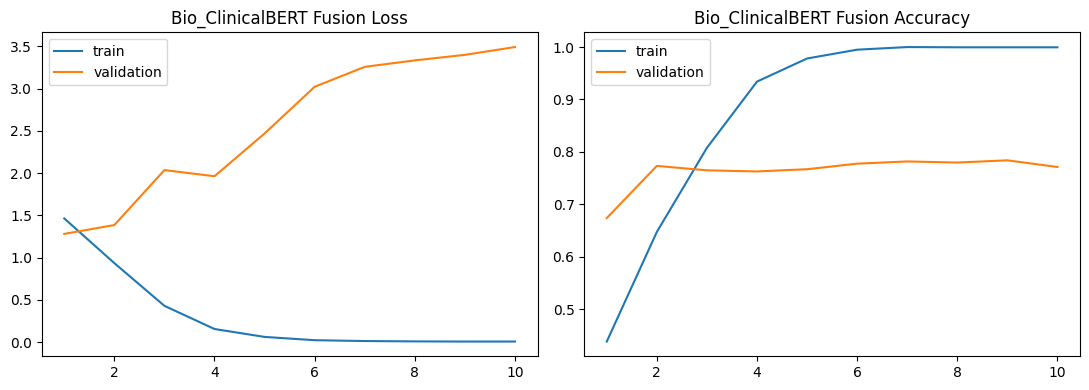

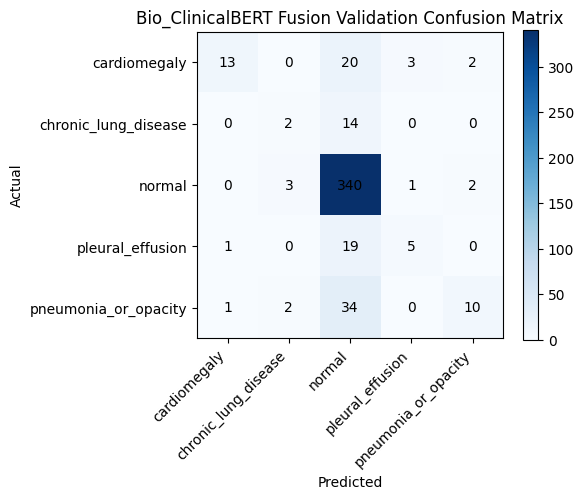

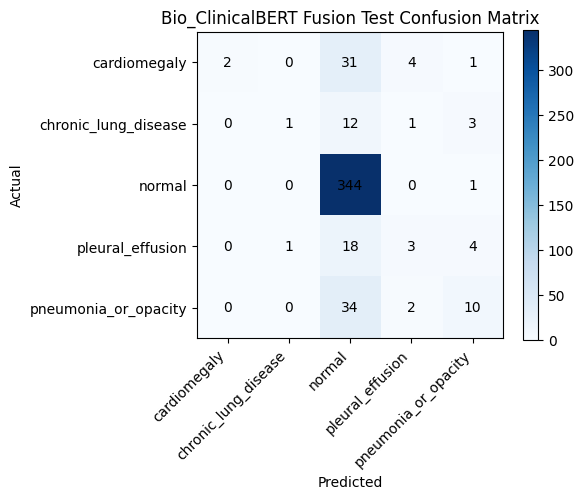

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,0.005901,0.999545,3.492344,0.771186,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,validation,cardiomegaly,0.866667,0.342105,0.490566,38.0
1,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,validation,chronic_lung_disease,0.285714,0.125000,0.173913,16.0
2,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,validation,normal,0.796253,0.982659,0.879690,346.0
3,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,validation,pleural_effusion,0.555556,0.200000,0.294118,25.0
4,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,validation,pneumonia_or_opacity,0.714286,0.212766,0.327869,47.0
5,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,test,cardiomegaly,1.000000,0.052632,0.100000,38.0
6,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,test,chronic_lung_disease,0.500000,0.058824,0.105263,17.0
7,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,test,normal,0.783599,0.997101,0.877551,345.0
8,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,test,pleural_effusion,0.300000,0.115385,0.166667,26.0
9,Bio_ClinicalBERT,bio_clinicalbert,fusion,42,test,pneumonia_or_opacity,0.526316,0.217391,0.307692,46.0


Bio_ClinicalBERT Fusion validation accuracy: 0.7839
Bio_ClinicalBERT Fusion test accuracy: 0.7627
Bio_ClinicalBERT Fusion test macro F1: 0.3114
Bio_ClinicalBERT Fusion test macro AUROC: 0.7886
Bio_ClinicalBERT Fusion test macro AUPRC: 0.4388
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\bio_clinicalbert_fusion\seed_42\best_checkpoint.pt



In [20]:
clinicalbert_spec = get_encoder_spec("bio_clinicalbert")
train_encoder_variation(clinicalbert_spec, run_summaries, per_class_tables)


### **Train RadBERT Text Encoder Variation**


Starting runs for RadBERT
Loading tokenizer for RadBERT: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\StanfordAIMI__RadBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\StanfordAIMI__RadBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RadBERT Text-Only - Epoch 1/10


Train radbert_text_only:   0%|                                                                  | 0/69 [00:00<…

...

Train radbert_text_only:   0%|                                                                  | 0/69 [00:00<…

Val radbert_text_only:   0%|                                                                    | 0/15 [00:00<…

train_loss=1.5464 | train_acc=0.3836 | val_loss=1.5559 | val_acc=0.4047



Best Val radbert_text_only:   0%|                                                               | 0/15 [00:00<…

Test radbert_text_only:   0%|                                                                   | 0/15 [00:00<…

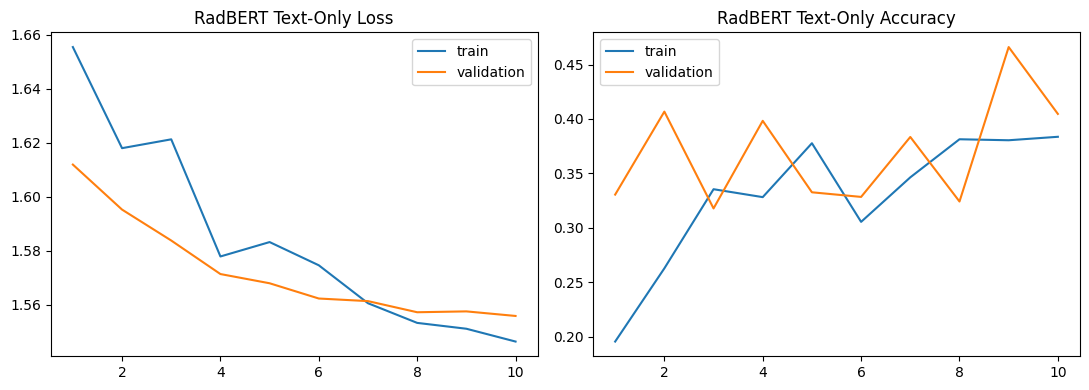

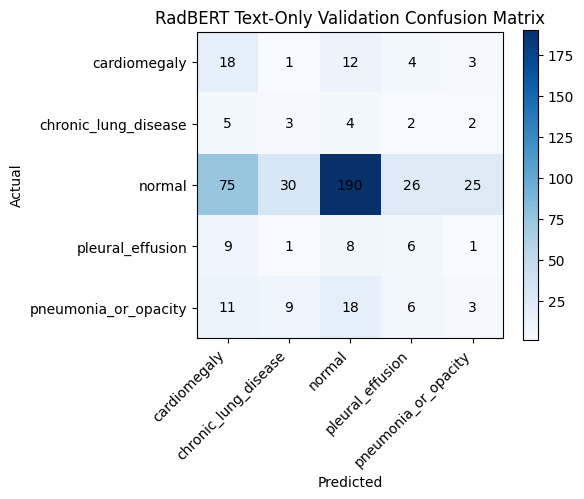

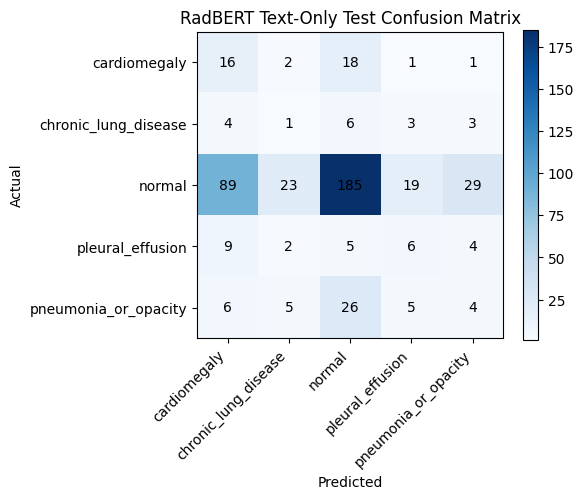

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,1.546391,0.383636,1.555863,0.404661,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,RadBERT,radbert,text_only,42,validation,cardiomegaly,0.152542,0.473684,0.230769,38.0
1,RadBERT,radbert,text_only,42,validation,chronic_lung_disease,0.068182,0.187500,0.100000,16.0
2,RadBERT,radbert,text_only,42,validation,normal,0.818966,0.549133,0.657439,346.0
3,RadBERT,radbert,text_only,42,validation,pleural_effusion,0.136364,0.240000,0.173913,25.0
4,RadBERT,radbert,text_only,42,validation,pneumonia_or_opacity,0.088235,0.063830,0.074074,47.0
5,RadBERT,radbert,text_only,42,test,cardiomegaly,0.129032,0.421053,0.197531,38.0
6,RadBERT,radbert,text_only,42,test,chronic_lung_disease,0.030303,0.058824,0.040000,17.0
7,RadBERT,radbert,text_only,42,test,normal,0.770833,0.536232,0.632479,345.0
8,RadBERT,radbert,text_only,42,test,pleural_effusion,0.176471,0.230769,0.200000,26.0
9,RadBERT,radbert,text_only,42,test,pneumonia_or_opacity,0.097561,0.086957,0.091954,46.0


RadBERT Text-Only validation accuracy: 0.4661
RadBERT Text-Only test accuracy: 0.4492
RadBERT Text-Only test macro F1: 0.2324
RadBERT Text-Only test macro AUROC: 0.6019
RadBERT Text-Only test macro AUPRC: 0.2341
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\radbert_text_only\seed_42\best_checkpoint.pt

Loading tokenizer for RadBERT: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\StanfordAIMI__RadBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\resolved_hf_models\StanfordAIMI__RadBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Train radbert_fusion:   0%|                                                                     | 0/69 [00:00<…

Val radbert_fusion:   0%|                                                                       | 0/15 [00:00<…

train_loss=0.0047 | train_acc=1.0000 | val_loss=3.7499 | val_acc=0.7797



Best Val radbert_fusion:   0%|                                                                  | 0/15 [00:00<…

Test radbert_fusion:   0%|                                                                      | 0/15 [00:00<…

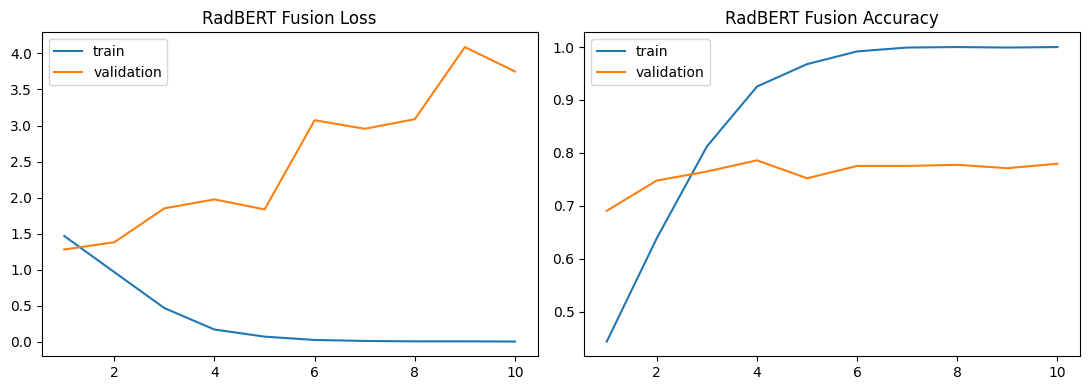

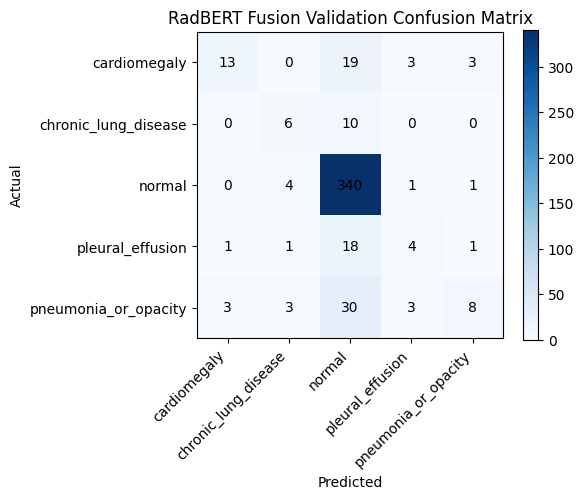

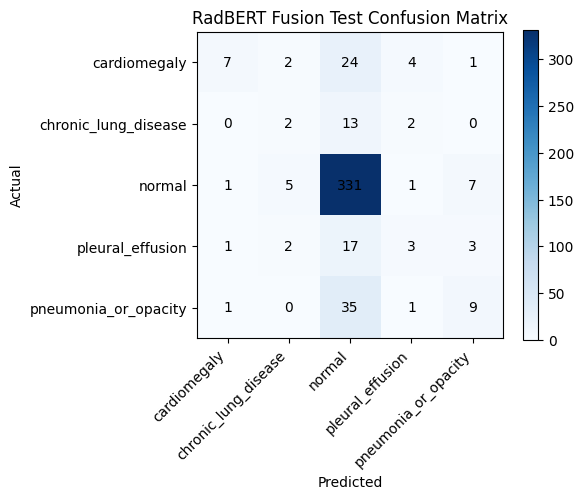

,epoch,train_loss,train_acc,val_loss,val_acc,lr_min,lr_max
9,10,0.004716,1.0,3.749908,0.779661,0.0001,0.0001


,encoder_name,encoder_slug,task_type,seed,split,class_name,precision,recall,f1_score,support
0,RadBERT,radbert,fusion,42,validation,cardiomegaly,0.764706,0.342105,0.472727,38.0
1,RadBERT,radbert,fusion,42,validation,chronic_lung_disease,0.428571,0.375000,0.400000,16.0
2,RadBERT,radbert,fusion,42,validation,normal,0.815348,0.982659,0.891219,346.0
3,RadBERT,radbert,fusion,42,validation,pleural_effusion,0.363636,0.160000,0.222222,25.0
4,RadBERT,radbert,fusion,42,validation,pneumonia_or_opacity,0.615385,0.170213,0.266667,47.0
5,RadBERT,radbert,fusion,42,test,cardiomegaly,0.700000,0.184211,0.291667,38.0
6,RadBERT,radbert,fusion,42,test,chronic_lung_disease,0.181818,0.117647,0.142857,17.0
7,RadBERT,radbert,fusion,42,test,normal,0.788095,0.959420,0.865359,345.0
8,RadBERT,radbert,fusion,42,test,pleural_effusion,0.272727,0.115385,0.162162,26.0
9,RadBERT,radbert,fusion,42,test,pneumonia_or_opacity,0.450000,0.195652,0.272727,46.0


RadBERT Fusion validation accuracy: 0.786
RadBERT Fusion test accuracy: 0.7458
RadBERT Fusion test macro F1: 0.347
RadBERT Fusion test macro AUROC: 0.7989
RadBERT Fusion test macro AUPRC: 0.4358
Best checkpoint: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\radbert_fusion\seed_42\best_checkpoint.pt



In [21]:
radbert_spec = get_encoder_spec("radbert")
train_encoder_variation(radbert_spec, run_summaries, per_class_tables)


---

# **Part 5: Results and Reporting**

### **Export Benchmark Summaries**


In [22]:
run_summary_df, aggregate_summary_df, per_class_summary_df = build_benchmark_summary_tables(
    run_summaries,
    per_class_tables,
)


Benchmark summaries refreshed.
Run summary CSV: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\run_summary.csv
Aggregate summary CSV: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\aggregate_summary.csv
Per-class summary CSV: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark\per_class_summary.csv


### **Review the Exported Summaries**


In [23]:
def hide_seed_columns(df):
    return df.drop(columns=["seed", "n_seeds", "seeds"], errors="ignore")

if 'run_summary_df' in globals() and not run_summary_df.empty:
    display(hide_seed_columns(run_summary_df))

if 'aggregate_summary_df' in globals() and not aggregate_summary_df.empty:
    display(hide_seed_columns(aggregate_summary_df))

if 'per_class_summary_df' in globals() and not per_class_summary_df.empty:
    display(hide_seed_columns(per_class_summary_df).head(12))


,encoder_name,encoder_slug,task_type,tokenizer_name,best_epoch,val_loss,val_accuracy,val_macro_f1,val_macro_auroc,val_macro_auprc,test_loss,test_accuracy,test_macro_f1,test_macro_auroc,test_macro_auprc,checkpoint_path,run_dir,source_notebook
0,DualImageResNet18,dual_image_resnet18,image_only,not_applicable,5,2.472141,0.766949,0.431304,0.819118,0.482566,2.886285,0.756356,0.359514,0.779358,0.449066,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,02 saved dual-image baseline artifacts
1,Bio_ClinicalBERT,bio_clinicalbert,text_only,emilyalsentzer/Bio_ClinicalBERT,2,1.598902,0.495763,0.240602,0.550474,0.234603,1.601571,0.502119,0.202833,0.561719,0.224999,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
2,CheXbert,chexbert,text_only,bert-base-uncased,2,1.639310,0.540254,0.235309,0.510734,0.218410,1.590279,0.557203,0.206747,0.596979,0.242445,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
3,CheXbert,chexbert,text_only,bert-base-uncased,2,1.639310,0.540254,0.235309,0.510734,0.218410,1.590279,0.557203,0.206747,0.596979,0.242445,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
4,RadBERT,radbert,text_only,StanfordAIMI/RadBERT,9,1.557553,0.466102,0.247239,0.611146,0.268464,1.577002,0.449153,0.232393,0.601850,0.234063,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
5,Bio_ClinicalBERT,bio_clinicalbert,fusion,emilyalsentzer/Bio_ClinicalBERT,9,3.400077,0.783898,0.433231,0.807967,0.486729,3.897526,0.762712,0.311435,0.788590,0.438786,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
6,CheXbert,chexbert,fusion,bert-base-uncased,4,1.872440,0.783898,0.495194,0.841768,0.495757,2.216563,0.750000,0.403914,0.784650,0.440264,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN
7,RadBERT,radbert,fusion,StanfordAIMI/RadBERT,4,1.975723,0.786017,0.450567,0.841240,0.501881,2.232812,0.745763,0.346955,0.798869,0.435795,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,NaN


,encoder_name,encoder_slug,task_type,tokenizer_name,test_accuracy_mean,test_macro_f1_mean,test_macro_auroc_mean,test_macro_auprc_mean
0,Bio_ClinicalBERT,bio_clinicalbert,fusion,emilyalsentzer/Bio_ClinicalBERT,0.762712,0.311435,0.788590,0.438786
1,CheXbert,chexbert,fusion,bert-base-uncased,0.750000,0.403914,0.784650,0.440264
2,RadBERT,radbert,fusion,StanfordAIMI/RadBERT,0.745763,0.346955,0.798869,0.435795
3,DualImageResNet18,dual_image_resnet18,image_only,not_applicable,0.756356,0.359514,0.779358,0.449066
4,CheXbert,chexbert,text_only,bert-base-uncased,0.557203,0.206747,0.596979,0.242445
5,Bio_ClinicalBERT,bio_clinicalbert,text_only,emilyalsentzer/Bio_ClinicalBERT,0.502119,0.202833,0.561719,0.224999
6,RadBERT,radbert,text_only,StanfordAIMI/RadBERT,0.449153,0.232393,0.601850,0.234063


,encoder_name,encoder_slug,task_type,split,class_name,precision,recall,f1-score,support,auroc,auprc,f1_score
0,DualImageResNet18,dual_image_resnet18,image_only,validation,cardiomegaly,0.916667,0.289474,0.440000,38.0,0.927844,0.613404,NaN
1,DualImageResNet18,dual_image_resnet18,image_only,validation,chronic_lung_disease,0.666667,0.250000,0.363636,16.0,0.903920,0.389814,NaN
2,DualImageResNet18,dual_image_resnet18,image_only,validation,normal,0.799043,0.965318,0.874346,346.0,0.791495,0.900891,NaN
3,DualImageResNet18,dual_image_resnet18,image_only,validation,pleural_effusion,0.444444,0.160000,0.235294,25.0,0.728054,0.239120,NaN
4,DualImageResNet18,dual_image_resnet18,image_only,validation,pneumonia_or_opacity,0.333333,0.191489,0.243243,47.0,0.744280,0.269600,NaN
5,DualImageResNet18,dual_image_resnet18,image_only,test,cardiomegaly,0.800000,0.105263,0.186047,38.0,0.884004,0.507307,NaN
6,DualImageResNet18,dual_image_resnet18,image_only,test,chronic_lung_disease,0.666667,0.117647,0.200000,17.0,0.830899,0.338992,NaN
7,DualImageResNet18,dual_image_resnet18,image_only,test,normal,0.790094,0.971014,0.871261,345.0,0.765286,0.887780,NaN
8,DualImageResNet18,dual_image_resnet18,image_only,test,pleural_effusion,0.444444,0.153846,0.228571,26.0,0.711970,0.216089,NaN
9,DualImageResNet18,dual_image_resnet18,image_only,test,pneumonia_or_opacity,0.387097,0.260870,0.311688,46.0,0.704634,0.295164,NaN


### **Benchmark Result Interpretation**

The encoder comparison is a narrowing step, not the final model decision. Bio_ClinicalBERT is the best handoff choice because it gives the strongest fusion accuracy and a stable clinical-language backbone for the gated-fusion test, while CheXbert's stronger macro F1 remains an important minority-class caveat. The main takeaway is that image-based fusion is still carrying performance, and later notebooks need to test whether architecture and preprocessing changes improve balanced abnormal-class behavior.

---

# **Part 6: Conclusion**

The fusion results did not produce a single winner across every metric. Bio_ClinicalBERT fusion had the strongest accuracy among the text-encoder fusion runs at 0.756, while CheXbert fusion had the strongest macro F1 at 0.415. Text-only models stayed much weaker than image-based models, which confirms that the report text alone is not enough to solve the task under this five-class label setup.

Bio_ClinicalBERT was chosen as the winner for the next stage because it gave the strongest overall held-out fusion accuracy while remaining a clinically appropriate, stable encoder for the project pipeline. That mattered because Notebook 03 was designed to test the fusion architecture itself, not to continue swapping language models. Carrying forward the most accurate Bio_ClinicalBERT fusion run gave the gated-fusion ablation a clear and recoverable backbone while keeping the next experiment focused on whether residual gated fusion improves the selected multimodal model.

It is also worth mentioning that CheXbert's stronger macro F1 is still an important caveat. It suggests CheXbert handled the minority-class balance better in this comparison, so Bio_ClinicalBERT should not be described as dominating every metric. Bio_ClinicalBERT wins the handoff because it combines the best fusion accuracy, strong clinical-language relevance, and a clean path into the residual gated fusion architecture that later notebooks evaluate.

---